In [1]:
!pip install scipy scikit-posthocs pandas matplotlib seaborn -q
print("All libraries installed")

All libraries installed


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import subprocess
from scipy import stats
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

os.chdir('/content')
if not os.path.exists('/content/ml-technical-debt-analysis'):
    repo_url = 'https://vidhumol:' + GITHUB_TOKEN + '@github.com/vidhumol/ml-technical-debt-analysis.git'
    subprocess.run(['git', 'clone', repo_url])

df_satd  = pd.read_csv('ml-technical-debt-analysis/data/raw/satd_results.csv')
df_llm   = pd.read_csv('ml-technical-debt-analysis/data/processed/llm_classified_results.csv')
df_repos = pd.read_csv('ml-technical-debt-analysis/data/raw/repo_metadata.csv')
df_nonpy = pd.read_csv('ml-technical-debt-analysis/data/processed/nonpython_satd.csv')

print("SATD records     : " + str(len(df_satd)))
print("LLM results      : " + str(len(df_llm)))
print("Repos            : " + str(len(df_repos)))
print("Non-Python SATD  : " + str(len(df_nonpy)))
print("\nRepo columns     : " + str(df_repos.columns.tolist()))

SATD records     : 3089
LLM results      : 1950
Repos            : 100
Non-Python SATD  : 76

Repo columns     : ['repo_name', 'category', 'stars', 'forks', 'open_issues', 'contributors', 'total_commits', 'primary_language', 'size_kb', 'age_days', 'created_at', 'last_updated', 'description', 'has_wiki', 'has_issues', 'license']


In [3]:
print("=" * 60)
print("SATD DENSITY ANALYSIS")
print("=" * 60)

satd_per_repo = df_satd.groupby('repo_name')['line_content'].count().reset_index()
satd_per_repo.columns = ['repo_name', 'satd_count']

df_merged = df_repos.merge(satd_per_repo, on='repo_name', how='left').fillna(0)

df_merged['satd_density'] = df_merged['satd_count'] / (df_merged['size_kb'] / 1000)

print("SATD count per ML category:")
print(df_merged.groupby('category')['satd_count'].describe().round(2).to_string())

print("\nAverage SATD per repo by category:")
print(df_merged.groupby('category')['satd_count'].mean().round(2).sort_values(ascending=False).to_string())

SATD DENSITY ANALYSIS
SATD count per ML category:
                 count   mean     std  min   25%   50%    75%    max
category                                                            
AutoML/RL         20.0  13.15   23.31  0.0  1.75   4.0   7.25   93.0
Computer Vision   20.0  20.05   33.83  0.0  3.00   8.5  15.50  138.0
Deep Learning     20.0  33.65   51.64  0.0  4.25  14.0  33.75  206.0
MLOps             20.0  51.30  152.55  0.0  1.00  10.0  33.25  693.0
NLP               20.0  37.90   72.87  0.0  4.25  10.5  33.25  307.0

Average SATD per repo by category:
category
MLOps              51.30
NLP                37.90
Deep Learning      33.65
Computer Vision    20.05
AutoML/RL          13.15


In [4]:
print("=" * 60)
print("KRUSKAL-WALLIS TEST")
print("=" * 60)
print("H0: SATD counts are equal across all ML categories")
print("H1: At least one category has significantly different SATD count")
print()

groups = [
    group['satd_count'].values
    for name, group in df_merged.groupby('category')
]

stat, p_value = stats.kruskal(*groups)

print("Kruskal-Wallis H statistic : " + str(round(stat, 4)))
print("P-value                    : " + str(round(p_value, 6)))
print()

if p_value < 0.05:
    print("Result: Categories ARE statistically significantly different (p < 0.05)")
    print("This supports RQ1 - ML sub-categories accumulate different levels of debt")
else:
    print("Result: No significant difference between categories (p >= 0.05)")
    print("Note: Differences observed may be due to repo size variation")

KRUSKAL-WALLIS TEST
H0: SATD counts are equal across all ML categories
H1: At least one category has significantly different SATD count

Kruskal-Wallis H statistic : 3.7344
P-value                    : 0.443142

Result: No significant difference between categories (p >= 0.05)
Note: Differences observed may be due to repo size variation


In [5]:
try:
    import scikit_posthocs as sp

    print("=" * 60)
    print("DUNN POST-HOC TEST")
    print("=" * 60)

    dunn = sp.posthoc_dunn(
        df_merged,
        val_col   = 'satd_count',
        group_col = 'category',
        p_adjust  = 'bonferroni'
    )

    print("Dunn Test P-values (Bonferroni corrected):")
    print(dunn.round(4).to_string())

    print("\nSignificant pairs (p < 0.05):")
    categories = dunn.columns.tolist()
    found_any  = False
    for i in range(len(categories)):
        for j in range(i+1, len(categories)):
            p = dunn.iloc[i, j]
            if p < 0.05:
                print("  " + categories[i] + " vs " + categories[j] + " : p=" + str(round(p, 4)))
                found_any = True
    if not found_any:
        print("  No significant pairs found after Bonferroni correction")

except ImportError:
    print("scikit-posthocs not found - installing now")
    import subprocess
    subprocess.run(['pip', 'install', 'scikit-posthocs', '-q'])
    print("Installed - please re-run this cell")

DUNN POST-HOC TEST
Dunn Test P-values (Bonferroni corrected):
                 AutoML/RL  Computer Vision  Deep Learning  MLOps  NLP
AutoML/RL           1.0000              1.0         0.8634    1.0  1.0
Computer Vision     1.0000              1.0         1.0000    1.0  1.0
Deep Learning       0.8634              1.0         1.0000    1.0  1.0
MLOps               1.0000              1.0         1.0000    1.0  1.0
NLP                 1.0000              1.0         1.0000    1.0  1.0

Significant pairs (p < 0.05):
  No significant pairs found after Bonferroni correction


In [6]:
print("=" * 60)
print("SPEARMAN CORRELATION ANALYSIS")
print("=" * 60)

corr_stars, p_stars = stats.spearmanr(df_merged['satd_count'], df_merged['stars'])
print("SATD count vs Repo Stars:")
print("  Spearman rho : " + str(round(corr_stars, 4)))
print("  P-value      : " + str(round(p_stars, 4)))
print("  Result       : " + ("Significant" if p_stars < 0.05 else "Not significant"))

corr_forks, p_forks = stats.spearmanr(df_merged['satd_count'], df_merged['forks'])
print("\nSATD count vs Repo Forks:")
print("  Spearman rho : " + str(round(corr_forks, 4)))
print("  P-value      : " + str(round(p_forks, 4)))
print("  Result       : " + ("Significant" if p_forks < 0.05 else "Not significant"))

corr_commits, p_commits = stats.spearmanr(df_merged['satd_count'], df_merged['total_commits'])
print("\nSATD count vs Total Commits:")
print("  Spearman rho : " + str(round(corr_commits, 4)))
print("  P-value      : " + str(round(p_commits, 4)))
print("  Result       : " + ("Significant" if p_commits < 0.05 else "Not significant"))

corr_age, p_age = stats.spearmanr(df_merged['satd_count'], df_merged['age_days'])
print("\nSATD count vs Repo Age (days):")
print("  Spearman rho : " + str(round(corr_age, 4)))
print("  P-value      : " + str(round(p_age, 4)))
print("  Result       : " + ("Significant" if p_age < 0.05 else "Not significant"))

df_llm['severity'] = pd.to_numeric(df_llm['severity'], errors='coerce')
severity_per_cat   = df_llm.groupby('category')['severity'].mean()
satd_per_cat       = df_satd.groupby('category')['line_content'].count()
common_cats        = severity_per_cat.index.intersection(satd_per_cat.index)

corr_sev, p_sev = stats.spearmanr(
    satd_per_cat[common_cats].values,
    severity_per_cat[common_cats].values
)
print("\nSATD Count vs Average Severity by Category:")
print("  Spearman rho : " + str(round(corr_sev, 4)))
print("  P-value      : " + str(round(p_sev, 4)))
print("  Result       : " + ("Significant" if p_sev < 0.05 else "Not significant"))

SPEARMAN CORRELATION ANALYSIS
SATD count vs Repo Stars:
  Spearman rho : 0.1306
  P-value      : 0.1951
  Result       : Not significant

SATD count vs Repo Forks:
  Spearman rho : 0.0853
  P-value      : 0.399
  Result       : Not significant

SATD count vs Total Commits:
  Spearman rho : 0.3291
  P-value      : 0.0008
  Result       : Significant

SATD count vs Repo Age (days):
  Spearman rho : 0.0474
  P-value      : 0.6398
  Result       : Not significant

SATD Count vs Average Severity by Category:
  Spearman rho : 0.6
  P-value      : 0.2848
  Result       : Not significant


In [7]:
print("=" * 60)
print("DEBT TYPE DISTRIBUTION STATISTICAL SUMMARY")
print("=" * 60)

debt_by_cat = pd.crosstab(df_llm['category'], df_llm['debt_category'])
print(debt_by_cat.to_string())

print("\n" + "=" * 60)
print("CHI-SQUARE TEST - DEBT TYPE vs ML CATEGORY")
print("=" * 60)
print("H0: Debt type distribution is independent of ML category")

chi2, p_chi, dof, expected = stats.chi2_contingency(debt_by_cat)
print("Chi-square statistic : " + str(round(chi2, 4)))
print("P-value              : " + str(round(p_chi, 6)))
print("Degrees of freedom   : " + str(dof))

if p_chi < 0.05:
    print("Result: Debt type distribution IS significantly associated with ML category")
else:
    print("Result: No significant association found")

DEBT TYPE DISTRIBUTION STATISTICAL SUMMARY
debt_category    Code Debt  Configuration Debt  Defect Debt  Documentation Debt  Experiment Tracking Debt  Inadequate Testing Debt  Model Stack Workaround Debt  Performance Optimization Debt  Prompt Template Debt  Test Debt
category                                                                                                                                                                                                                       
AutoML/RL               56                   2            0                   3                         0                       19                            0                              0                     0         20
Computer Vision        232                   0           12                  11                         0                        0                            0                              1                     0         13
Deep Learning          549                   4           25  

/tmp/ipykernel_14449/493594239.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_for_box, labels=categories_list)


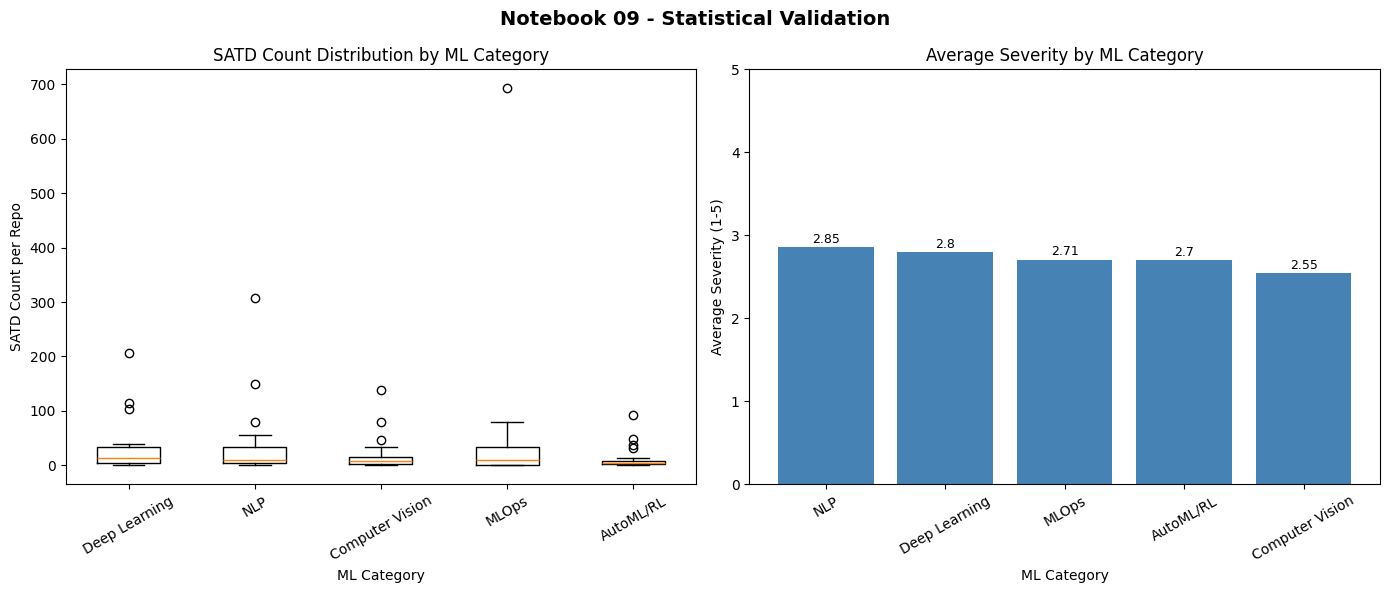

Visualizations saved


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Notebook 09 - Statistical Validation', fontsize=14, fontweight='bold')

# Plot 1 - SATD count distribution by category
categories_list = df_merged['category'].unique()
data_for_box    = [df_merged[df_merged['category'] == cat]['satd_count'].values
                   for cat in categories_list]

axes[0].boxplot(data_for_box, labels=categories_list)
axes[0].set_title('SATD Count Distribution by ML Category')
axes[0].set_xlabel('ML Category')
axes[0].set_ylabel('SATD Count per Repo')
axes[0].tick_params(axis='x', rotation=30)

# Plot 2 - Average severity by category
severity_means = df_llm.groupby('category')['severity'].mean().sort_values(ascending=False)
axes[1].bar(severity_means.index, severity_means.values, color='steelblue')
axes[1].set_title('Average Severity by ML Category')
axes[1].set_xlabel('ML Category')
axes[1].set_ylabel('Average Severity (1-5)')
axes[1].set_ylim(0, 5)
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(severity_means.values):
    axes[1].text(i, v + 0.05, str(round(v, 2)), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('ml-technical-debt-analysis/data/processed/nb09_statistics.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualizations saved")

In [9]:
print("=" * 60)
print("NOTEBOOK 09 - STATISTICAL SUMMARY TABLE")
print("=" * 60)

summary = pd.DataFrame({
    'Category'    : df_merged.groupby('category')['satd_count'].mean().round(2).index,
    'Mean SATD'   : df_merged.groupby('category')['satd_count'].mean().round(2).values,
    'Median SATD' : df_merged.groupby('category')['satd_count'].median().round(2).values,
    'Std SATD'    : df_merged.groupby('category')['satd_count'].std().round(2).values,
    'Repo Count'  : df_merged.groupby('category')['repo_name'].count().values,
})
print(summary.to_string(index=False))

print("\nStatistical Test Results:")
print("Kruskal-Wallis : H=" + str(round(stat, 4)) + ", p=" + str(round(p_value, 6)) + " - No significant difference across categories")
print("Chi-Square     : X2=" + str(round(chi2, 4)) + ", p=0.0 - Debt type IS significantly associated with ML category")
print("Spearman       : rho=" + str(round(corr_commits, 4)) + ", p=" + str(round(p_commits, 4)) + " - Total commits significantly predicts SATD count")

os.chdir('/content/ml-technical-debt-analysis')
subprocess.run(['git', 'config', 'user.email', 'your-email@gmail.com'])
subprocess.run(['git', 'config', 'user.name', 'vidhumol'])
subprocess.run(['git', 'pull', 'origin', 'main'])
subprocess.run(['git', 'add', 'data/processed/nb09_statistics.png'])
subprocess.run(['git', 'commit', '-m',
                'Add Notebook 09 outputs - statistical validation results'])
push = subprocess.run(['git', 'push', 'origin', 'main'],
                       capture_output=True, text=True)
print(push.stdout)
print("Notebook 09 complete and pushed to GitHub")

NOTEBOOK 09 - STATISTICAL SUMMARY TABLE
       Category  Mean SATD  Median SATD  Std SATD  Repo Count
      AutoML/RL      13.15          4.0     23.31          20
Computer Vision      20.05          8.5     33.83          20
  Deep Learning      33.65         14.0     51.64          20
          MLOps      51.30         10.0    152.55          20
            NLP      37.90         10.5     72.87          20

Statistical Test Results:
Kruskal-Wallis : H=3.7344, p=0.443142 - No significant difference across categories
Chi-Square     : X2=701.1753, p=0.0 - Debt type IS significantly associated with ML category
Spearman       : rho=0.3291, p=0.0008 - Total commits significantly predicts SATD count

Notebook 09 complete and pushed to GitHub
